In [1]:
# reload modules on import
%load_ext autoreload
%autoreload 2
# imports
import numpy as np

## Tuning the regressorlens
The following notebook is concerned with finding good hyperparameters for the regressorlens.
We will focus on R2 performance on the canonical validation set defined in the data loader. This includes models from earlt, middle and final stages of training in equal proportions

First let's load in the data

In [2]:
from cnn_surgery.utils.load_dataset import load_dataset
early = load_dataset('mnist', metrics_file='metrics_merged_mnist_early.csv', load_class_acc=True, stage='early')
middle = load_dataset('mnist', metrics_file='metrics_merged_mnist_middle.csv', load_class_acc=True, stage='middle')
final = load_dataset('mnist', metrics_file='metrics_merged.csv', load_class_acc=True, stage='final')

train_early, test_early, val_early = early
train_middle, test_middle, val_middle = middle
train_final, test_final, val_final = final

weights_train = np.concatenate([train_early[0], train_middle[0], train_final[0]])
weights_val = np.concatenate([val_early[0], val_middle[0], val_final[0]])

accuracies_train = np.concatenate([train_early[1][:, -10:], train_middle[1][:, -10:], train_final[1][:, -10:]])
accuracies_val = np.concatenate([val_early[1][:, -10:], val_middle[1][:, -10:], val_final[1][:, -10:]])

dirname:  /Users/ilic/Documents/CWI/Explainability and Interpretability/WeightSpaceClassifier/model_zoo/mnist


dirname:  /Users/ilic/Documents/CWI/Explainability and Interpretability/WeightSpaceClassifier/model_zoo/mnist


dirname:  /Users/ilic/Documents/CWI/Explainability and Interpretability/WeightSpaceClassifier/model_zoo/mnist


In [3]:
print(f"Train set size: {len(weights_train)}, Validation set size: {len(weights_val)}")

Train set size: 45000, Validation set size: 22494


Let's have a look at the default config

In [4]:
from cnn_surgery.lenses.regressor_lens import get_regressor_lens, default_config
config = default_config.copy()
config

{'optimizer_name': 'Adam',
 'learning_rate': 0.0004,
 'w_init_name': 'kaiming',
 'init_stddev': 0.05,
 'l2_penalty': 2e-05,
 'n_layers': 5,
 'n_hiddens': 256,
 'dropout_rate': 0.03,
 'batch_size': 512}

I think it makes sense to stick with Adam since everybody uses that nowadays. For initialisation, I do not see a reason not to stick with pytorch standard kaiming / he normal.

What we probably should tune: (in order of importance)
* Batch Size
* Learning Rate
* Architecture (depth / width)
* L2 Penalty
* Dropout rate

Using results from Unterthiner as an educated guess. These came from a hyperparameter tuning effort so they are oddly specific

In [5]:
config['early_stopping'] = True  # enable early stopping


Starting training of RegressorLens:
Epoch   1 ─ val loss 0.028631 | val MAE 0.096137 | duration 2.1s
Epoch   2 ─ val loss 0.023305 | val MAE 0.083318 | duration 1.4s
Epoch   3 ─ val loss 0.021764 | val MAE 0.080949 | duration 1.6s
Epoch   4 ─ val loss 0.019515 | val MAE 0.073088 | duration 1.5s
Epoch   5 ─ val loss 0.017362 | val MAE 0.068527 | duration 1.6s
Epoch   6 ─ val loss 0.017690 | val MAE 0.071238 | duration 1.4s
Epoch   7 ─ val loss 0.016903 | val MAE 0.066715 | duration 1.5s
Epoch   8 ─ val loss 0.016156 | val MAE 0.062996 | duration 1.4s
Epoch   9 ─ val loss 0.015674 | val MAE 0.061640 | duration 1.5s
Epoch  10 ─ val loss 0.015685 | val MAE 0.062396 | duration 1.6s
Epoch  11 ─ val loss 0.016336 | val MAE 0.062493 | duration 1.3s
Epoch  12 ─ val loss 0.016058 | val MAE 0.062492 | duration 1.2s
Epoch  13 ─ val loss 0.014690 | val MAE 0.059540 | duration 1.9s
Epoch  14 ─ val loss 0.016815 | val MAE 0.065001 | duration 1.6s
Epoch  15 ─ val loss 0.015026 | val MAE 0.060390 | du

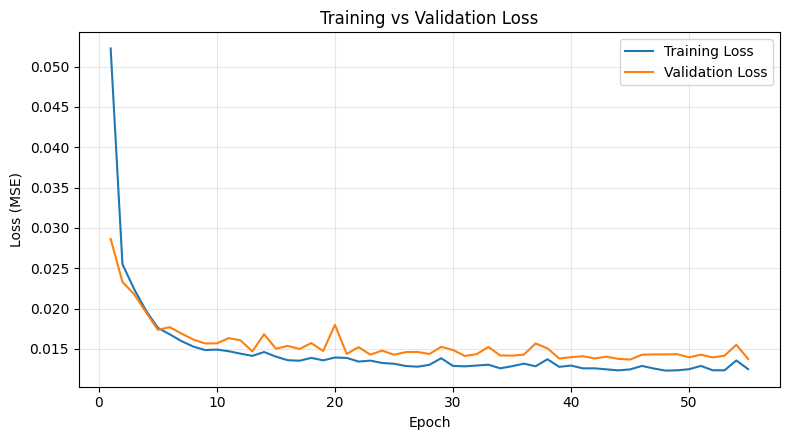


========== FINAL REPORT ==========
Test MSE = 0.013745
Test MAE = 0.055870
Test R2  = 0.923343


(FCN(
   (flatten): Flatten(start_dim=1, end_dim=-1)
   (hidden): Sequential(
     (0): Linear(in_features=4970, out_features=256, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.03, inplace=False)
     (3): Linear(in_features=256, out_features=256, bias=True)
     (4): ReLU()
     (5): Dropout(p=0.03, inplace=False)
     (6): Linear(in_features=256, out_features=256, bias=True)
     (7): ReLU()
     (8): Dropout(p=0.03, inplace=False)
     (9): Linear(in_features=256, out_features=256, bias=True)
     (10): ReLU()
     (11): Dropout(p=0.03, inplace=False)
     (12): Linear(in_features=256, out_features=256, bias=True)
     (13): ReLU()
     (14): Dropout(p=0.03, inplace=False)
   )
   (out): Linear(in_features=256, out_features=10, bias=True)
 ),
 ((0.011711869801746475, 0.049741287602318655),
  (0.01374454459126943, 0.05587046185821875),
  0.9233431737919412))

In [6]:
# T for mps: 2.99s, 3.12s
get_regressor_lens(weights_train, accuracies_train, weights_val, accuracies_val, verbose=True, config=config, return_metrics=True)

In [7]:
config['learning_rate'] = 5e-4
config['w_init_name'] = 'kaiming'
config['n_layers'] = 5
config['n_hiddens'] = 1024

In [8]:
config

{'optimizer_name': 'Adam',
 'learning_rate': 0.0005,
 'w_init_name': 'kaiming',
 'init_stddev': 0.05,
 'l2_penalty': 2e-05,
 'n_layers': 5,
 'n_hiddens': 1024,
 'dropout_rate': 0.03,
 'batch_size': 512,
 'early_stopping': True}